# Move models between JAX, Keras, TensorFlow and PyTorch

Runnable locally on CPU or on a Cloud TPU VM.

- Map Dense and Linear weight axes and verify a known output.
- Separate architecture, weights, non-trainable state, optimizer state and preprocessing.
- Run a backend-neutral Keras model and explain the boundaries of tensor exchange and export.

You have a dense layer in PyTorch and the same model idea in Keras. Can you reuse the weights in JAX? We’ll start with one small layer, work out a prediction by hand, and check the weight axes. From there, you’ll learn which parts of a model can transfer directly and which need separate checks.

## The idea

Cross-framework conversion must preserve the meaning of inputs, parameters and outputs. A layout transpose can be necessary, but architecture, preprocessing and arithmetic conventions must agree too. Start by writing the function each framework computes.

## Map the function, not just the weight file

For a dense layer, one framework may store weights as input-by-output while another stores output-by-input. The transpose can align the intended multiplication. If both dimensions happen to match, an incorrect mapping may still have a legal shape.

Use unequal dimensions and distinguishable values, then compare intermediate results on the same input. Check bias placement, activation and normalization conventions instead of inferring equivalence from a successful load.

The transpose heatmaps show storage correspondence. They do not demonstrate conversion of an arbitrary Keras, TensorFlow or PyTorch architecture. A supported converter needs an explicit model-family contract, including tokenizer or image/audio processor identity where relevant.

### Pause and reason

Why is a square weight matrix a weak first conversion test?

<details><summary>Compare your reasoning</summary>

The wrong orientation can still have the expected shape. Unequal dimensions and independently known values make layout mistakes easier to detect.

</details>

## A parameter file is not a model

Our inputs have shape $[\mathrm{batch}, 3]$. Keras Dense uses a $[3, 2]$ kernel; PyTorch Linear stores $[2, 3]$ weights and multiplies by their transpose. Bias has shape $[2]$. For $x=[1, 2, -1]$, the first output is $1+1+1+0.1=3.1$. Verify a hand-derived row before comparing whole arrays. Convolution kernels have additional layout conventions; do not apply this dense transpose rule to them.

## Use Keras as a shared model vocabulary

Keras $3$ can execute models on JAX, TensorFlow or PyTorch. Select KERAS_BACKEND before importing keras, in a fresh process. Use `keras.layers` and `keras.ops` in portable model code; a call to tf.* inside a custom layer is a TensorFlow dependency. This does not port arbitrary Python side effects or framework-specific training loops. A .keras archive preserves Keras configuration and weights; an inference export has a different job.

## Explicit JAX state is a design decision

Pass parameters and non-trainable state explicitly; return updated state and keep random keys visible. A matched inference result does not show that dropout randomness, BatchNorm moving statistics or optimizer slots were transferred. Start in inference mode with `training=False.` Compare gradients and an update separately before claiming training equivalence. Reinitializing the optimizer is a new training run, not an exact resume.

## Choose the bridge for the destination

NumPy exchange makes a clear host copy and usually breaks autodiff across the boundary. DLPack exchanges supported tensor buffers between frameworks; sharing memory is not model conversion or cross-framework autodiff, and external mutation can violate JAX assumptions. JAX export serializes a staged computation for compatible consumers. jax2tf is a separate, version-sensitive TensorFlow bridge. Keras export can target supported inference formats; inspect the destination operators and signatures. ONNX is a model interchange format, while ONNX Runtime execution providers choose supported execution paths. PyTorch/XLA runs PyTorch through XLA; it does not turn a PyTorch model into an explicit JAX function.

## Run the optional real-framework lab

The file labs/keras_backends.py beside this lesson builds the same Dense model, fixes its weights, compares known outputs, and inspects mixed precision policy. From the extracted course workspace root, use an isolated environment with Keras and the backend you want. Run the same file in a new process for each backend; --backend selects it before importing Keras. Tested locally with Keras 3.14.1 on the installed JAX and PyTorch backends. The same companion also passed on TensorFlow 2.21.0 with Keras 3.15.1 in the separate edge-lab environment. These optional backend checks are recorded separately from the core CPU receipt.

**Optional Keras environment — macOS/Linux, workspace root**

```sh
# Run optional keras environment — macos/linux, workspace root using the course Python environment
python3 -m venv .venv-interop
.venv-interop/bin/python -m pip install "keras==3.14.1" "jax==0.9.2" "torch==2.11.0"
```

**Expected:** An isolated environment with the tested Keras/JAX/PyTorch versions. Use .venv-interop/bin/python instead of python3 in the commands below; on Windows use .venv-interop\Scripts\python.exe. TensorFlow is a separate optional backend: use the edge lab environment instructions and record its installed versions.

**Optional lab — run from the course workspace root after installing Keras and the selected backend**

```sh
# Run optional lab — run from the course workspace root after installing keras and the selected backend using the course Python environment
python3 phases/15-deployment/01-keras-and-pytorch-bridges-to-explicit-jax/labs/keras_backends.py --backend jax
python3 phases/15-deployment/01-keras-and-pytorch-bridges-to-explicit-jax/labs/keras_backends.py --backend torch
python3 phases/15-deployment/01-keras-and-pytorch-bridges-to-explicit-jax/labs/keras_backends.py --backend tensorflow
```

**Expected:** Each installed backend prints PASS and measured precision errors. A missing backend must be installed in its isolated environment before running that command.

## Write the same dense layer in both layouts

We’ll call the input matrix $X$, the Keras-style kernel $W$, and the PyTorch-style weight $W_{\mathrm{torch}}$. The math agrees when $W=W_{\mathrm{torch}}^\mathsf{T}$. The transpose changes how weights are arranged, not what the layer means. Bias $b$ is added to every output row. Check the known first row before trying a larger model.

$$
Y=XW+b=XW_{\mathrm{torch}}^\mathsf{T}+b
$$

## A valid shape can still mean the wrong feature

Imagine that the source reads temperature, pressure and humidity in that order. The target reads humidity, pressure and temperature. Both receive three numbers, so a shape assertion passes. But the first coefficient now multiplies the wrong measurement. Write down feature names and units next to each input column before mapping a weight tensor.

For the worked first row, the two scores are $1+1+1+0.1=3.1$ and $-2+2-0.25-0.2=-0.45$. Swapping the first and last features gives $-0.9$ and $4.05$. These large differences are not floating-point noise. Follow the first mismatch: raw values, normalized values, first layer, activation, then output labels. This order prevents you from adjusting a numerical tolerance to conceal a different function.

### Pause and reason

If the target swaps input features and also swaps the matching rows of its kernel, should its output change?

<details><summary>Compare your reasoning</summary>

No. Both changes restore each feature–coefficient pairing. Swapping only the values or only the rows changes the function. This is a semantic alignment check, separate from changing the storage layout from input-by-output to output-by-input.

</details>

## Use a small bridge before a complete model

Keep the dense example as a test you can reason through by hand. Then add one operation at a time: a nonlinearity, normalization, and a second layer. Record an intermediate tensor at each boundary. For a convolution, declare both image layout and kernel layout; for attention, declare token order, head order, masks, and how query, key and value weights are packed.

The optional Keras lab runs real backends in separate processes. The default companion below uses NumPy and JAX to expose the mapping arithmetic, so its success alone is verified separately from TensorFlow, PyTorch, or a complete pretrained checkpoint. Carry a table of source names, target names, shapes, axis permutations and test inputs into the model-specific conversion lesson.

## Write the source function and its known input

Create main.py in your lesson workspace and run it with the active course Python environment. Keep feature order fixed while you name the input, kernel and bias.

In [1]:
# Step 1 — Write the source function and its known input: The arrays define a batch of shape (2,3), a kernel of shape (3,2),...
# Import numpy for this computation.
import numpy as np
import jax
import jax.numpy as jnp
# Same dense layer, different parameter layouts.
x = np.array([[1., 2., -1.], [-2., 0., 3.]], np.float32)
# Compute `keras_kernel` from `np.array([[1., -2.], [.5, 1.], [-1., .25]], np.float32)`
keras_kernel = np.array([[1., -2.], [.5, 1.], [-1., .25]], np.float32)
# Compute `bias` from `np.array([.1, -.2], np.float32)`
bias = np.array([.1, -.2], np.float32)

# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(x[0] @ keras_kernel + bias, [3.1, -.45], atol=1e-6)

The arrays define a batch of shape $(2,3)$, a kernel of shape $(3,2)$, and a bias of shape $(2,)$. The first known output is $[3.1,-0.45]$.

## Map the stored tensor into explicit JAX parameters

Append this block to the same main.py and rerun the whole file. Transpose the stored PyTorch-style weights back into input-by-output order, then define the pure prediction function.

In [2]:
# Step 2 — Map the stored tensor into explicit JAX parameters: The zero-input check returns the bias twice.
torch_weight = keras_kernel.T.copy()  # torch Linear: output, input
# Create device-backed JAX array `params`.
params = {"kernel": jnp.asarray(torch_weight.T), "bias": jnp.asarray(bias)}
# Function `predict(params, inputs)` implementing this stage's computation:
def predict(params, inputs):
    # Return `inputs @ params['kernel'] + params['bias']` to the caller.
    return inputs @ params["kernel"] + params["bias"]

# Allocate initialized array `` with the specified shape and dtype.
np.testing.assert_allclose(predict(params, jnp.zeros((2,3))), np.tile(bias,(2,1)), atol=1e-6)

The zero-input check returns the bias twice. If it does not, inspect bias broadcasting before comparing full predictions.

## Verify values before extending the architecture

Append this block to the same main.py and rerun the whole file. Run both independent checks and inspect the two output rows.

In [3]:
# Step 3 — Verify values before extending the architecture: The first assertion checks hand arithmetic; the second compares...
# Wrap with `jax.jit` (`actual`) so XLA traces and compiles the function.
actual = np.asarray(jax.jit(predict)(params, jnp.asarray(x)))
# A hand-computed first row detects a shared layout mistake.
np.testing.assert_allclose(actual[0], [3.1, -.45], atol=1e-6)
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(actual, x @ keras_kernel + bias, atol=1e-6)
# Print the observed values to compare against the expected result.
print("Matched dense outputs:", actual)

Matched dense outputs: [[ 3.1  -0.45]
 [-4.9   4.55]]


The first assertion checks hand arithmetic; the second compares the entire batch with the source-layout calculation. Continue with the feature-order and second-layer experiments below.

## Run the example

In [4]:
# Move models between JAX, Keras, TensorFlow and PyTorch: Cross-framework conversion must preserve the meaning of inputs,...
# Import numpy for this computation.
import numpy as np
import jax
import jax.numpy as jnp
# Same dense layer, different parameter layouts.
x = np.array([[1., 2., -1.], [-2., 0., 3.]], np.float32)
# Compute `keras_kernel` from `np.array([[1., -2.], [.5, 1.], [-1., .25]], np.float32)`
keras_kernel = np.array([[1., -2.], [.5, 1.], [-1., .25]], np.float32)
# Compute `bias` from `np.array([.1, -.2], np.float32)`
bias = np.array([.1, -.2], np.float32)
torch_weight = keras_kernel.T.copy()  # torch Linear: output, input
# Create device-backed JAX array `params`.
params = {"kernel": jnp.asarray(torch_weight.T), "bias": jnp.asarray(bias)}
# Function `predict(params, inputs)` implementing this stage's computation:
def predict(params, inputs):
    # Return `inputs @ params['kernel'] + params['bias']` to the caller.
    return inputs @ params["kernel"] + params["bias"]
# Wrap with `jax.jit` (`actual`) so XLA traces and compiles the function.
actual = np.asarray(jax.jit(predict)(params, jnp.asarray(x)))
# A hand-computed first row detects a shared layout mistake.
np.testing.assert_allclose(actual[0], [3.1, -.45], atol=1e-6)
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(actual, x @ keras_kernel + bias, atol=1e-6)
# Print the observed values to compare against the expected result.
print("Matched dense outputs:", actual)

Matched dense outputs: [[ 3.1  -0.45]
 [-4.9   4.55]]


Expected: Two rows match; the first is $[3.1, -0.45]$ within absolute tolerance $10^{-6}$.

## A transpose changes storage layout, not the intended model

Predict: Which axis names swap between the two parameter layouts?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: A transpose changes storage layout, not the intended model
# Compute `visual_data` from `{'kind': 'panels', 'panels': [{'kind': 'heatmap', 't...`
visual_data = {'kind': 'panels', 'panels': [{'kind': 'heatmap', 'title': 'Input × output layout', 'values': keras_kernel.tolist(), 'rows': ['input 0', 'input 1', 'input 2'], 'columns': ['output 0', 'output 1'], 'unit': 'weight'}, {'kind': 'heatmap', 'title': 'Output × input layout', 'values': torch_weight.tolist(), 'rows': ['output 0', 'output 1'], 'columns': ['input 0', 'input 1', 'input 2'], 'unit': 'weight'}]}

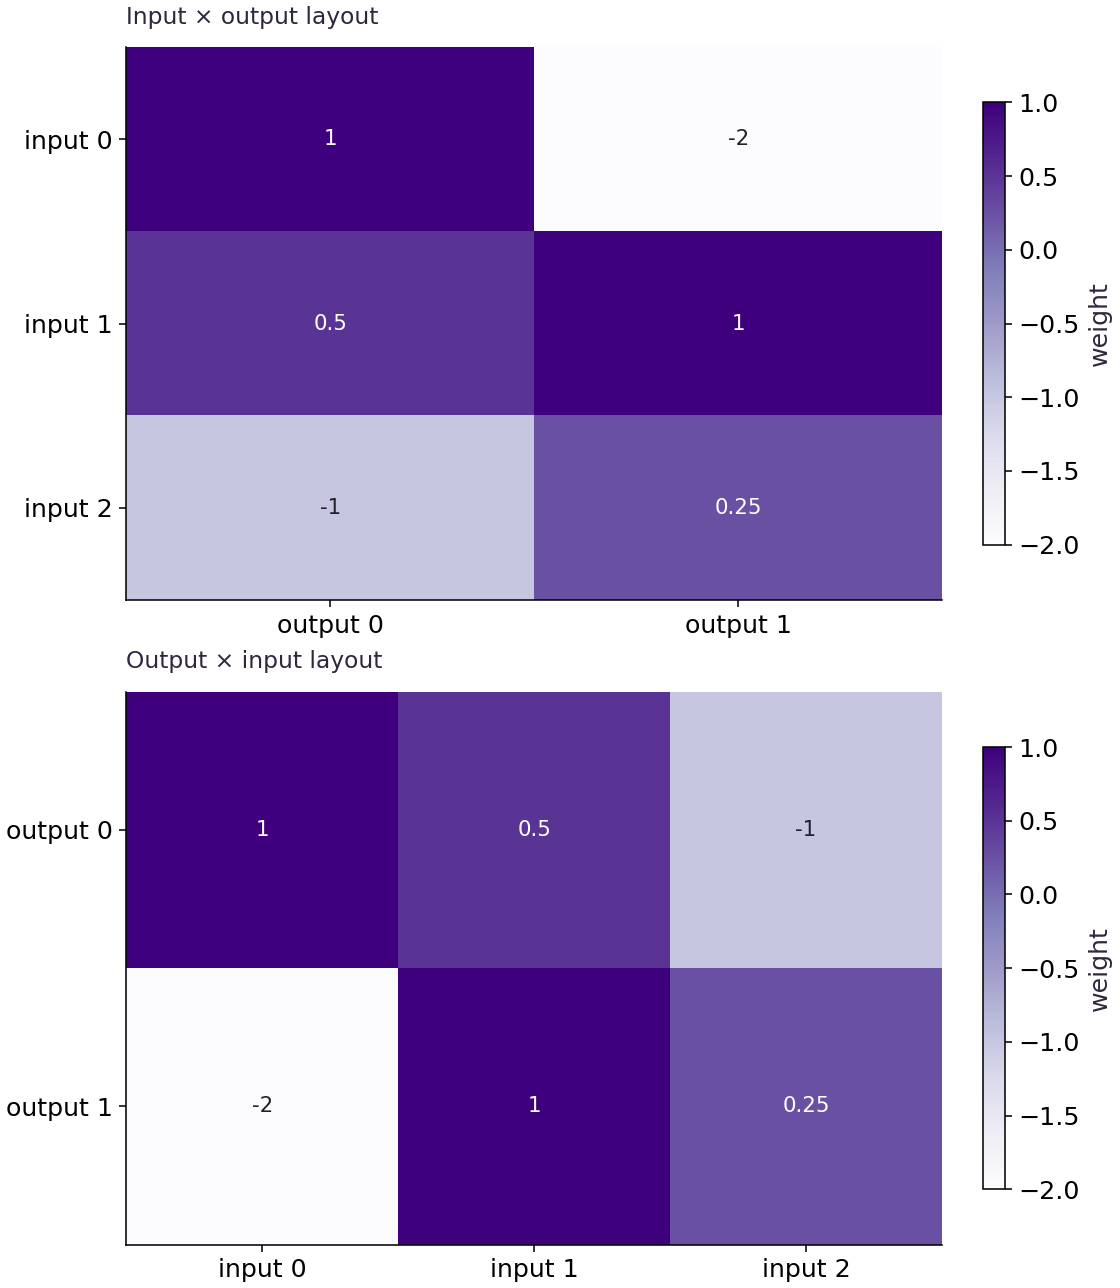

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The upper matrix has input features as rows and output features as columns. The lower matrix swaps those axes. The cell values are weights, and the two panels contain the same six numbers in transposed positions.

Track the weight $-1$: it moves from input $2$, output $0$ in the upper panel to output $0$, input $2$ in the lower panel. It still connects the same input feature to the same output feature. The layout changes from shape $(3,2)$ to $(2,3)$.

### Connect it to the computation

With the first convention, a row batch computes $XW+b$. With the transposed storage convention, the equivalent calculation uses $X\widetilde W^{\mathsf T}+b$, where $\widetilde W=W^{\mathsf T}$. Transposing storage without adapting the computation would change the meaning or produce a shape error.

The picture explains this layout contract using an explicit numerical reference. It does not demonstrate that every layer or serialized model can be transferred between frameworks by one transpose. Check activations, bias, preprocessing, and layer-specific conventions against an independent output reference as well.

## A square matrix hides a transpose

Predict: Will a shape check catch wrong axes when input and output dimensions are equal?

In [7]:
# Experiment — A square matrix hides a transpose: Check asymmetric values and independently known outputs, not...
# Compute `square` from `np.array([[1., 2.], [3., 4.]], np.float32)`
square = np.array([[1., 2.], [3., 4.]], np.float32)
# Compute `z` from `np.array([[2., -1.]], np.float32)`
z = np.array([[2., -1.]], np.float32)
# Check tensor shape invariant: `(z @ square).shape == (z @ square.T).shape`
assert (z @ square).shape == (z @ square.T).shape
# Assert that `not np.allclose(z @ square, z @ square.T)`.
assert not np.allclose(z @ square, z @ square.T)
# Print the observed values to compare against the expected result.
print("Equal shapes, unequal outputs")

Equal shapes, unequal outputs


Expected: Both outputs have the same shape but different values.

Check asymmetric values and independently known outputs, not just tensor dimensions.

## Reorder features without changing tensor dimensions

Predict: Predict both scores if the first and last input features are exchanged while the weights stay fixed.

In [8]:
# Experiment — Reorder features without changing tensor dimensions: The repair changes the pairing of features and coefficients.
permutation = [2, 1, 0]
# Compute `reordered` from `x[:, permutation]`
reordered = x[:, permutation]
# Convert `wrong_order` to a host NumPy array for inspection or verification.
wrong_order = np.asarray(predict(params, reordered))
# Compute `np.testing.assert_allclose(wrong_order[0], [-.9, 4.05], atol` as `1e-6)`.
np.testing.assert_allclose(wrong_order[0], [-.9, 4.05], atol=1e-6)
# Assert that `not np.allclose(wrong_order, actual)`.
assert not np.allclose(wrong_order, actual)
# Compute `repaired_params` from `{'kernel': params['kernel'][permutation, :], 'bias':...`
repaired_params = {'kernel': params['kernel'][permutation, :], 'bias': params['bias']}
# Compute `np.testing.assert_allclose(predict(repaired_params, reordered), actual, atol` as `1e-6)`.
np.testing.assert_allclose(predict(repaired_params, reordered), actual, atol=1e-6)
# Print the observed values to compare against the expected result.
print('Feature order failed, then matched after aligning kernel rows.')

Feature order failed, then matched after aligning kernel rows.


Expected: The wrong first row is $[-0.9,4.05]$; permuting the kernel rows restores both original observations.

The repair changes the pairing of features and coefficients. It does not change the model represented by those pairings. Repeat with asymmetric feature values; repeated values can hide a wrong order.

## Your exercise

Add a batch with four rows and preserve the same parameters. Verify each row independently using a feature-by-feature sum.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `array.reshape(new_shape)` — Reorganizes tensor axes without changing the total element count (`array.size`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Construct and reshape `changed` into the target tensor dimensions.
2. Combine or mask array elements to form `expected`.
3. Compute `np.testing.assert_allclose(predict(params, changed), expected, atol` as `2e-6)`.
4. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Add a batch with four rows and preserve the same parameters.
# Construct and reshape `changed` into the target tensor dimensions.
changed = np.arange(...)  # TODO: compute changed
# Combine or mask array elements to form `expected`.
expected = np.stack(...)  # TODO: compute expected
# Compute `np.testing.assert_allclose(predict(params, changed), expected, atol` as `2e-6)`.
np.testing.assert_allclose(predict(params, changed), expected, atol = ...  # TODO: compute np.testing.assert_allclose(predict(params, changed), expected, atol
# Print the observed values to compare against the expected result.
print("Changed batch verified")
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Add a batch with four rows and preserve the same parameters.
# Construct and reshape `changed` into the target tensor dimensions.
# changed = np.arange(...)  # TODO: compute changed
# Combine or mask array elements to form `expected`.
# expected = np.stack(...)  # TODO: compute expected
# Compute `np.testing.assert_allclose(predict(params, changed), expected, atol` as `2e-6)`.
# np.testing.assert_allclose(predict(params, changed), expected, atol = ...  # TODO: compute np.testing.assert_allclose(predict(params, changed), expected, atol
# Print the observed values to compare against the expected result.
# print("Changed batch verified")

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Add a batch with four rows and preserve the same parameters.
# Construct and reshape `changed` into the target tensor dimensions.
changed = np.arange(12, dtype=np.float32).reshape(4, 3) / 4
# Combine or mask array elements to form `expected`.
expected = np.stack([sum(row[i] * keras_kernel[i] for i in range(3)) + bias for row in changed])
# Compute `np.testing.assert_allclose(predict(params, changed), expected, atol` as `2e-6)`.
np.testing.assert_allclose(predict(params, changed), expected, atol=2e-6)
# Print the observed values to compare against the expected result.
print("Changed batch verified")

Changed batch verified


## Detect a preprocessing mismatch · Transfer

Suppose the source model expects inputs divided by $255$, while the target receives raw pixels. Demonstrate why correct weight transfer still fails.

Hint: Compute both predictions from the same raw input: once with the source normalization and once without it. Matching weights cannot cancel an input-scale mismatch.

### How to write: Detect a preprocessing mismatch — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Compute `pixels` from `np.array([[255., 128., 0.]], np.float32)`
2. Run `predict` to compute `source`.
3. Run `predict` to compute `wrong`.
4. Assert that `not np.allclose(source, wrong)`.
5. Compute `np.testing.assert_allclose(source, predict(params, pixels / 255.), atol` as `1e-6)`.

**Starter code scaffold (fill in the TODOs):**

```python
# Detect a preprocessing mismatch (Transfer): Input normalization belongs in the deployment contract.
# Compute `pixels` from `np.array([[255., 128., 0.]], np.float32)`
pixels = np.array(...)  # TODO: compute pixels
# Run `predict` to compute `source`.
source = predict(...)  # TODO: compute source
# Run `predict` to compute `wrong`.
wrong = predict(...)  # TODO: compute wrong
# Assert that `not np.allclose(source, wrong)`.
assert not np.allclose(source, wrong)  # TODO: complete assertion check
# Compute `np.testing.assert_allclose(source, predict(params, pixels / 255.), atol` as `1e-6)`.
np.testing.assert_allclose(source, predict(params, pixels / 255.), atol=1e-6)
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Detect a preprocessing mismatch (Transfer): Input normalization belongs in the deployment contract.
# Compute `pixels` from `np.array([[255., 128., 0.]], np.float32)`
# pixels = np.array(...)  # TODO: compute pixels
# Run `predict` to compute `source`.
# source = predict(...)  # TODO: compute source
# Run `predict` to compute `wrong`.
# wrong = predict(...)  # TODO: compute wrong
# Assert that `not np.allclose(source, wrong)`.
# assert not np.allclose(source, wrong)  # TODO: complete assertion check
# Compute `np.testing.assert_allclose(source, predict(params, pixels / 255.), atol` as `1e-6)`.
# np.testing.assert_allclose(source, predict(params, pixels / 255.), atol=1e-6)

## Reference reasoning

Input normalization belongs in the deployment contract. Matching weights cannot compensate for a different input distribution.

In [12]:
# Detect a preprocessing mismatch (Transfer): Input normalization belongs in the deployment contract.
# Compute `pixels` from `np.array([[255., 128., 0.]], np.float32)`
pixels = np.array([[255., 128., 0.]], np.float32)
# Run `predict` to compute `source`.
source = predict(params, pixels / 255.)
# Run `predict` to compute `wrong`.
wrong = predict(params, pixels)
# Assert that `not np.allclose(source, wrong)`.
assert not np.allclose(source, wrong)
# Compute `np.testing.assert_allclose(source, predict(params, pixels / 255.), atol` as `1e-6)`.
np.testing.assert_allclose(source, predict(params, pixels / 255.), atol=1e-6)

## Map a second layer and locate an omitted activation · Transfer / diagnosis

Extend the dense mapping with ReLU and a second dense layer. Use independently computed final scores to catch a converter that forgets ReLU. Then show why an all-positive probe would be a weak test.

Hint: Compute both first-layer rows by hand, replace negative entries by zero, and apply the new output weights.

### How to write: Map a second layer and locate an omitted activation — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Compute `second_kernel` from `np.array([[2.], [-1.]], np.float32)`
2. Compute `second_bias` from `np.array([.3], np.float32)`
3. Convert `hidden` to a host NumPy array for inspection or verification.
4. Perform matrix contraction / projection to compute `bridged_scores`.
5. Compute `np.testing.assert_allclose(bridged_scores[:, 0], [6.5, -4.25], atol` as `2e-6)`.

**Starter code scaffold (fill in the TODOs):**

```python
# Map a second layer and locate an omitted activation (Transfer / diagnosis): The first dense layer agrees, but the activation is the...
# Compute `second_kernel` from `np.array([[2.], [-1.]], np.float32)`
second_kernel = np.array(...)  # TODO: compute second_kernel
# Compute `second_bias` from `np.array([.3], np.float32)`
second_bias = np.array(...)  # TODO: compute second_bias
# Convert `hidden` to a host NumPy array for inspection or verification.
hidden = np.maximum(...)  # TODO: compute hidden
# Perform matrix contraction / projection to compute `bridged_scores`.
bridged_scores = ...  # TODO: compute bridged_scores
# Compute `np.testing.assert_allclose(bridged_scores[:, 0], [6.5, -4.25], atol` as `2e-6)`.
np.testing.assert_allclose(bridged_scores[:, 0], [6.5, -4.25], atol=2e-6)
# Convert `omitted_relu` to a host NumPy array for inspection or verification.
omitted_relu = np.asarray(...)  # TODO: compute omitted_relu
# Assert that `not np.allclose(omitted_relu, bridged_scores)`.
assert not np.allclose(omitted_relu, bridged_scores)  # TODO: complete assertion check
# Compute `positive_probe` from `np.array([[1., 2.]], np.float32)`
positive_probe = np.array(...)  # TODO: compute positive_probe
# Execute `np.testing.assert_array_equal(np.maximum(positive_probe, 0), positive_probe)`.
np.testing.assert_array_equal(np.maximum(positive_probe, 0), positive_probe)
# Print the observed values to compare against the expected result.
print('Two-layer reference scores:', bridged_scores[:, 0])
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Map a second layer and locate an omitted activation (Transfer / diagnosis): The first dense layer agrees, but the activation is the...
# Compute `second_kernel` from `np.array([[2.], [-1.]], np.float32)`
# second_kernel = np.array(...)  # TODO: compute second_kernel
# Compute `second_bias` from `np.array([.3], np.float32)`
# second_bias = np.array(...)  # TODO: compute second_bias
# Convert `hidden` to a host NumPy array for inspection or verification.
# hidden = np.maximum(...)  # TODO: compute hidden
# Perform matrix contraction / projection to compute `bridged_scores`.
# bridged_scores = ...  # TODO: compute bridged_scores
# Compute `np.testing.assert_allclose(bridged_scores[:, 0], [6.5, -4.25], atol` as `2e-6)`.
# np.testing.assert_allclose(bridged_scores[:, 0], [6.5, -4.25], atol=2e-6)
# Convert `omitted_relu` to a host NumPy array for inspection or verification.
# omitted_relu = np.asarray(...)  # TODO: compute omitted_relu
# Assert that `not np.allclose(omitted_relu, bridged_scores)`.
# assert not np.allclose(omitted_relu, bridged_scores)  # TODO: complete assertion check
# Compute `positive_probe` from `np.array([[1., 2.]], np.float32)`
# positive_probe = np.array(...)  # TODO: compute positive_probe
# Execute `np.testing.assert_array_equal(np.maximum(positive_probe, 0), positive_probe)`.
# np.testing.assert_array_equal(np.maximum(positive_probe, 0), positive_probe)
# Print the observed values to compare against the expected result.
# print('Two-layer reference scores:', bridged_scores[:, 0])

## Reference reasoning

The first dense layer agrees, but the activation is the first divergent boundary. The final reference scores are $6.5$ and $-4.25$. A probe containing only positive hidden values would make an omitted ReLU invisible.

In [14]:
# Map a second layer and locate an omitted activation (Transfer / diagnosis): The first dense layer agrees, but the activation is the...
# Compute `second_kernel` from `np.array([[2.], [-1.]], np.float32)`
second_kernel = np.array([[2.], [-1.]], np.float32)
# Compute `second_bias` from `np.array([.3], np.float32)`
second_bias = np.array([.3], np.float32)
# Convert `hidden` to a host NumPy array for inspection or verification.
hidden = np.maximum(np.asarray(predict(params, x)), 0.)
# Perform matrix contraction / projection to compute `bridged_scores`.
bridged_scores = hidden @ second_kernel + second_bias
# Compute `np.testing.assert_allclose(bridged_scores[:, 0], [6.5, -4.25], atol` as `2e-6)`.
np.testing.assert_allclose(bridged_scores[:, 0], [6.5, -4.25], atol=2e-6)
# Convert `omitted_relu` to a host NumPy array for inspection or verification.
omitted_relu = np.asarray(predict(params, x)) @ second_kernel + second_bias
# Assert that `not np.allclose(omitted_relu, bridged_scores)`.
assert not np.allclose(omitted_relu, bridged_scores)
# Compute `positive_probe` from `np.array([[1., 2.]], np.float32)`
positive_probe = np.array([[1., 2.]], np.float32)
# Execute `np.testing.assert_array_equal(np.maximum(positive_probe, 0), positive_probe)`.
np.testing.assert_array_equal(np.maximum(positive_probe, 0), positive_probe)
# Print the observed values to compare against the expected result.
print('Two-layer reference scores:', bridged_scores[:, 0])

Two-layer reference scores: [ 6.5  -4.25]


## Checkpoint

The Dense predictions match after transposing weights. What has been established?

1. The tested inference mapping matches for these inputs.
2. Optimizer and random state are now equivalent.
3. Any runtime can execute the model.

## Diagnose

If output shapes fail, write the contraction axes. If shapes match but values drift, check layout, preprocessing, bias, inference mode and dtype in that order. A missing TensorFlow import in the optional lab means that backend is not installed; it is not a failure of the JAX core exercise.

## Evidence

Keep the layout map, two changed-input comparisons, runtime versions and optional backend-lab output. Identify which model state and preprocessing are not covered by a dense-layer match.

## Primary references

- [Keras multi-backend migration](https://keras.io/guides/migrating_to_keras_3/)
- [Keras inference export](https://keras.io/api/models/model_saving_apis/export/)
- [JAX DLPack contract](https://docs.jax.dev/en/latest/_autosummary/jax.dlpack.from_dlpack.html)